# Music Clustering Project — Spotify Audio Features

**Goal:** group songs into clusters based on their audio features (danceability, energy,
valence, etc.) using unsupervised learning, then interpret what each cluster represents
musically.

**Models covered:** K-Means, Hierarchical (Agglomerative), DBSCAN, Gaussian Mixture Model (GMM)

**Workflow:**
1. Load & explore the data
2. Clean & preprocess (scale features)
3. Dimensionality reduction (PCA) for visualization
4. K-Means (Elbow method + Silhouette Score)
5. Hierarchical Clustering (Dendrogram)
6. DBSCAN
7. Gaussian Mixture Model
8. Compare models & interpret clusters


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load & Explore the Data

In [2]:
df = pd.read_csv("ML_spotify_data.csv")
print(df.shape)
df.head()


(10000, 12)


,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          10000 non-null  str    
 1   artists       10000 non-null  str    
 2   popularity    10000 non-null  int64  
 3   danceability  10000 non-null  float64
 4   valence       10000 non-null  float64
 5   energy        10000 non-null  float64
 6   explicit      10000 non-null  int64  
 7   key           10000 non-null  int64  
 8   liveness      10000 non-null  float64
 9   loudness      10000 non-null  float64
 10  speechiness   10000 non-null  float64
 11  tempo         10000 non-null  float64
dtypes: float64(7), int64(3), str(2)
memory usage: 1.3 MB


In [4]:
df.describe()


,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,37.556800,0.549507,0.523148,0.592609,0.103200,5.20560,0.209787,-9.822324,0.081426,120.179723
std,12.559743,0.178097,0.261456,0.251808,0.304235,3.56205,0.193693,5.321064,0.100472,30.260748
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-60.000000,0.000000,0.000000
25%,27.000000,0.430000,0.313000,0.414000,0.000000,2.00000,0.093900,-12.347250,0.034200,96.191250
50%,36.000000,0.557000,0.524500,0.616000,0.000000,5.00000,0.129000,-8.762000,0.045100,118.330500
75%,46.000000,0.681000,0.742000,0.801000,0.000000,9.00000,0.261250,-6.070750,0.077400,139.609500
max,86.000000,0.986000,0.996000,1.000000,1.000000,11.00000,1.000000,1.073000,0.957000,224.437000


In [5]:
# Missing values and duplicates
print("Missing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
 name            0
artists         0
popularity      0
danceability    0
valence         0
energy          0
explicit        0
key             0
liveness        0
loudness        0
speechiness     0
tempo           0
dtype: int64

Duplicate rows: 1


## 2. Clean & Preprocess

- Drop duplicate rows
- Select the numeric **audio feature** columns to cluster on
  (we exclude `name`, `artists` — identifiers, not audio features — and keep
  `popularity` out of the clustering features too, since it reflects listener
  behaviour rather than the sound of the track; we'll use it afterwards to help
  interpret the clusters).
- Standardize features (mean 0, std 1) since K-Means/DBSCAN/GMM are distance-based
  and our features are on very different scales (e.g. `loudness` in dB vs `tempo` in BPM).


In [6]:
df = df.drop_duplicates().reset_index(drop=True)

feature_cols = ["danceability", "valence", "energy", "explicit",
                 "key", "liveness", "loudness", "speechiness", "tempo"]

X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled.head()


,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,0.721506,0.137205,-0.637769,-0.339247,-0.619309,-0.707836,-0.540039,-0.478059,-0.082793
1,-0.525009,-1.010251,-0.891936,-0.339247,0.222937,-0.277511,-0.163422,-0.531806,0.780008
2,-0.654152,1.185215,0.521868,-0.339247,-1.461555,-0.205187,0.003650,-0.434265,-1.184320
3,-0.637307,1.326734,1.276427,-0.339247,-0.057812,3.333499,0.538883,-0.203353,1.778728
4,0.670972,0.156329,-0.717197,-0.339247,0.503685,0.988150,-0.615024,-0.134676,-1.370204


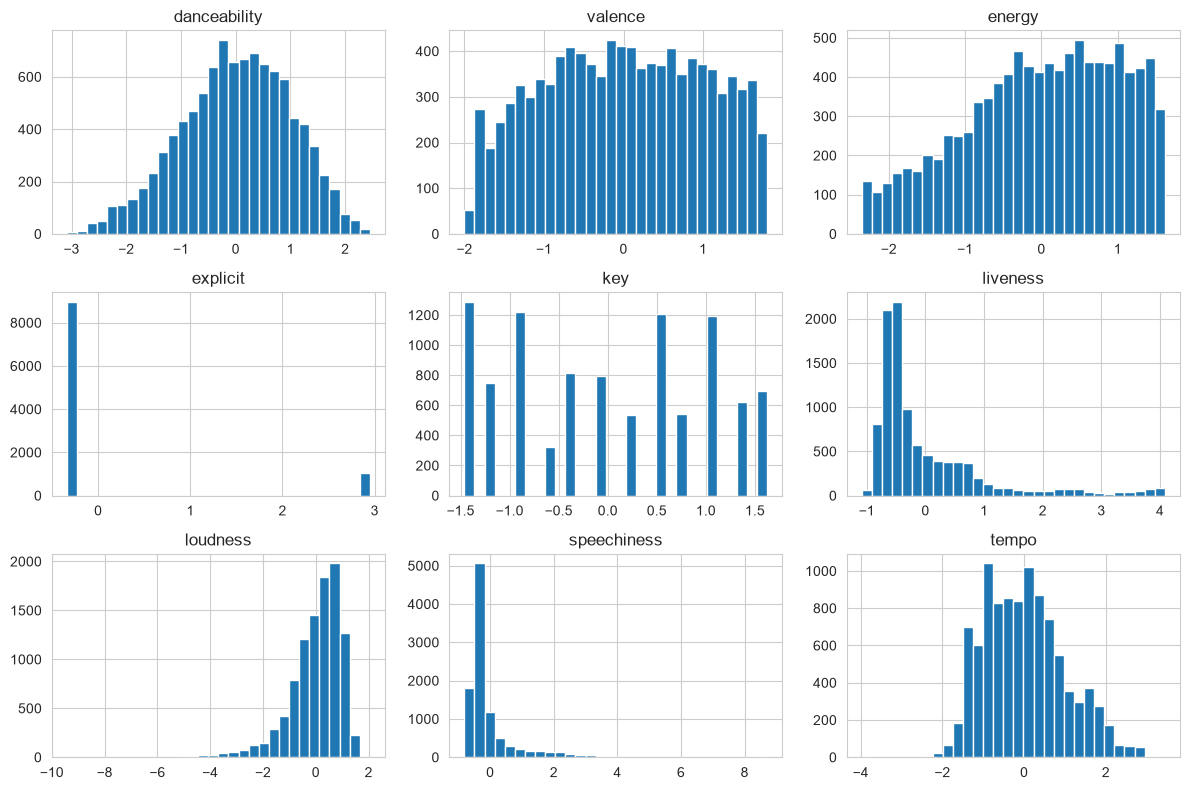

In [7]:
# Quick look at feature distributions after scaling
X_scaled.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


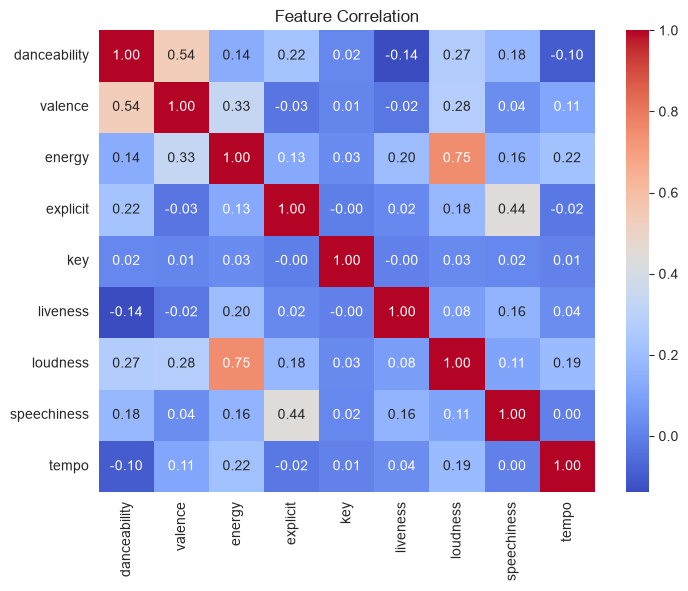

In [8]:
# Correlation heatmap - helps spot redundant features before clustering
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation")
plt.show()


## 3. Dimensionality Reduction (PCA)

We'll use PCA to compress the 9 scaled features down to 2 components purely for
**visualization** — plotting clusters in 2D is much easier to interpret than in
9D. We'll keep the full scaled feature set for the actual clustering.


Explained variance ratio: [0.26173808 0.15600064]
Total variance captured by 2 PCs: 0.418


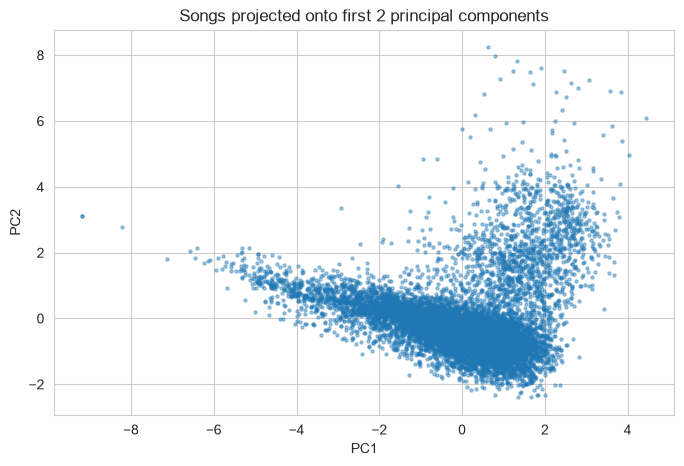

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 PCs:", pca.explained_variance_ratio_.sum().round(3))

plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Songs projected onto first 2 principal components")
plt.show()


## 4. K-Means Clustering

### 4.1 Elbow Method
We fit K-Means for a range of k values and plot the within-cluster sum of squares
(inertia). Look for the "elbow" — the point where adding more clusters stops giving
a big drop in inertia.


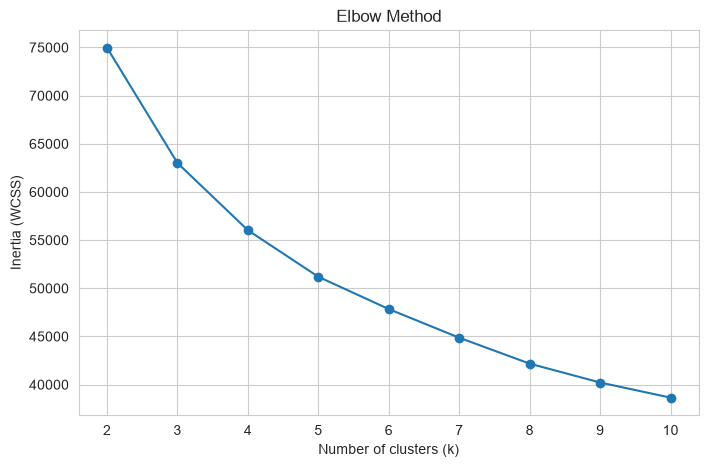

In [10]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.show()


### 4.2 Silhouette Score
The silhouette score (range -1 to 1) measures how well-separated the clusters are.
Higher is better. We check it across the same range of k to help pick a value that
both the elbow plot and silhouette score support.

Note: for 10,000 points, computing silhouette on the full dataset is fine, but if you
add many more rows later, consider `silhouette_score(X, labels, sample_size=2000)`.


k=2: silhouette=0.170
k=3: silhouette=0.215
k=4: silhouette=0.181
k=5: silhouette=0.182
k=6: silhouette=0.167
k=7: silhouette=0.175
k=8: silhouette=0.166
k=9: silhouette=0.162
k=10: silhouette=0.161


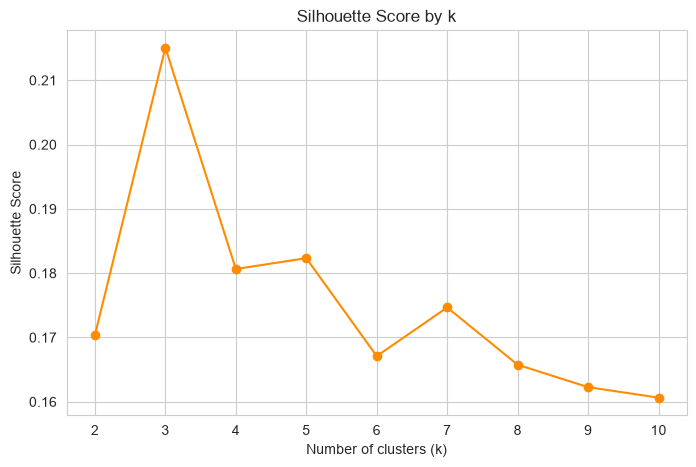

In [11]:
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}: silhouette={score:.3f}")

plt.plot(list(k_range), sil_scores, marker="o", color="darkorange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.show()


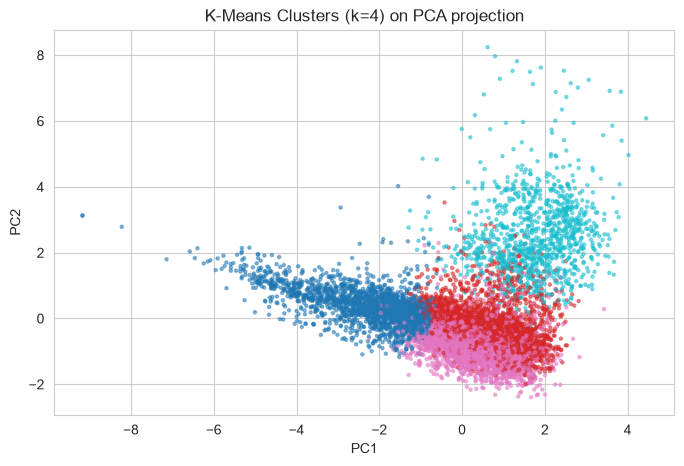

In [12]:
# Pick k based on the plots above (edit this once you've inspected them)
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["kmeans_cluster"], cmap="tab10", s=5, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters (k={best_k}) on PCA projection")
plt.show()


## 5. Hierarchical Clustering

Dendrograms on 10,000 points are unreadable and slow to compute (the full linkage
matrix is O(n²) memory), so we build the dendrogram on a random sample, then fit
`AgglomerativeClustering` with a chosen number of clusters on the full scaled data.


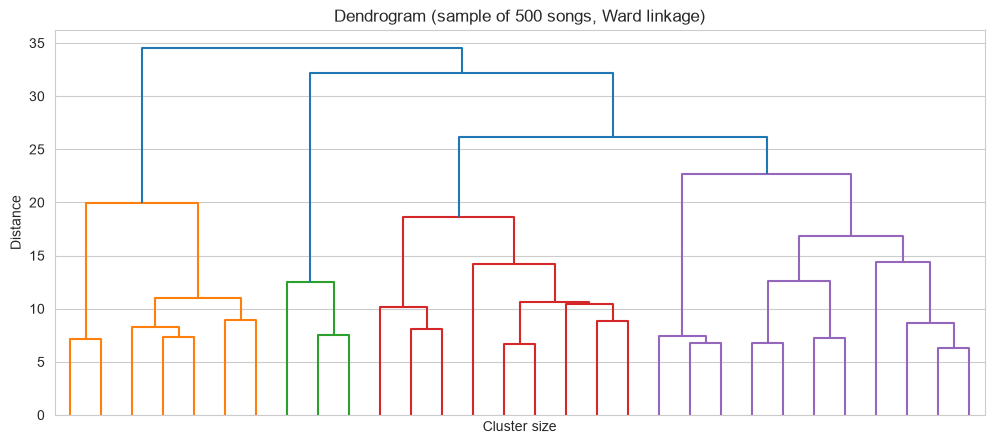

In [13]:
sample_idx = np.random.RandomState(42).choice(X_scaled.index, size=500, replace=False)
X_sample = X_scaled.loc[sample_idx]

linked = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="lastp", p=30, no_labels=True)
plt.title("Dendrogram (sample of 500 songs, Ward linkage)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()


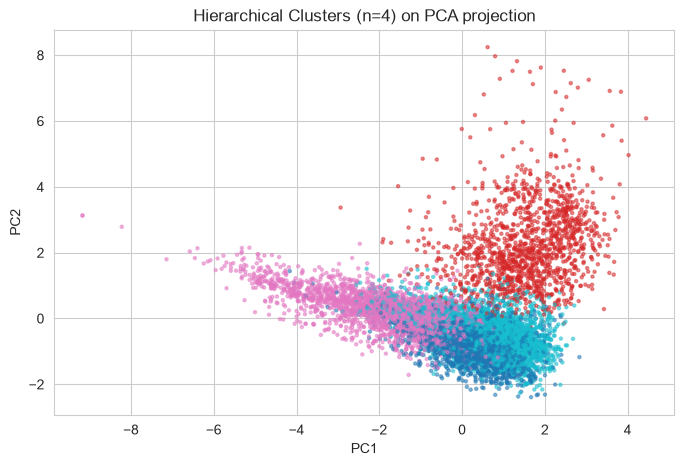

In [14]:
# Fit Agglomerative Clustering on the full data using a chosen number of clusters
n_clusters_hier = 4

hier = AgglomerativeClustering(n_clusters=n_clusters_hier, linkage="ward")
df["hierarchical_cluster"] = hier.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["hierarchical_cluster"], cmap="tab10", s=5, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical Clusters (n={n_clusters_hier}) on PCA projection")
plt.show()


## 6. DBSCAN

DBSCAN doesn't need a predefined number of clusters — instead it needs `eps`
(neighbourhood radius) and `min_samples`. We use a **k-distance plot** to pick a
reasonable `eps`: sort each point's distance to its k-th nearest neighbor and look
for the "knee".


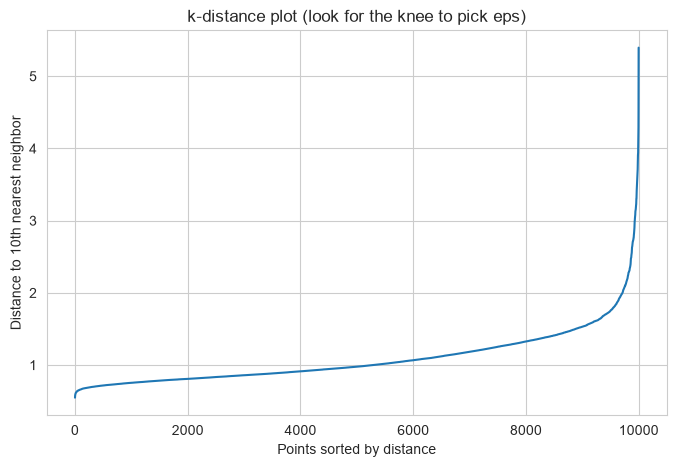

In [15]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("k-distance plot (look for the knee to pick eps)")
plt.show()


Clusters found: 2
Noise points: 435 (4.4%)


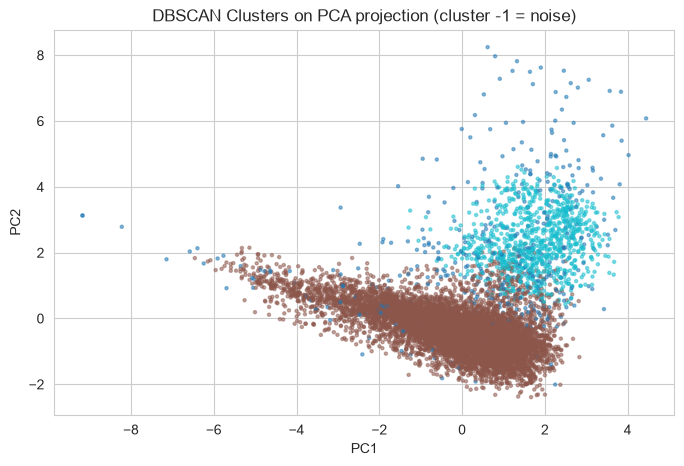

In [16]:
# Set eps based on the knee in the plot above
eps = 1.5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_clusters_found = len(set(df["dbscan_cluster"])) - (1 if -1 in df["dbscan_cluster"].values else 0)
n_noise = (df["dbscan_cluster"] == -1).sum()
print(f"Clusters found: {n_clusters_found}")
print(f"Noise points: {n_noise} ({n_noise/len(df):.1%})")

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["dbscan_cluster"], cmap="tab10", s=5, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters on PCA projection (cluster -1 = noise)")
plt.show()


## 7. Gaussian Mixture Model (GMM)

GMM is a probabilistic, "soft" clustering method. We use BIC (Bayesian Information
Criterion) to pick the number of components — lower BIC is better.


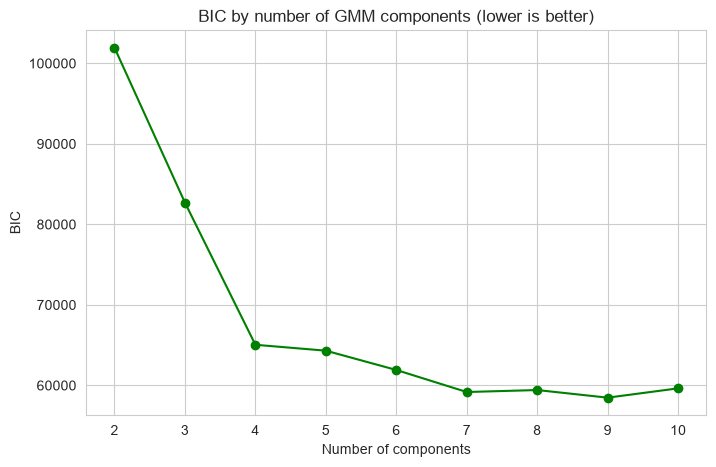

In [17]:
bics = []
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))

plt.plot(list(k_range), bics, marker="o", color="green")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC by number of GMM components (lower is better)")
plt.show()


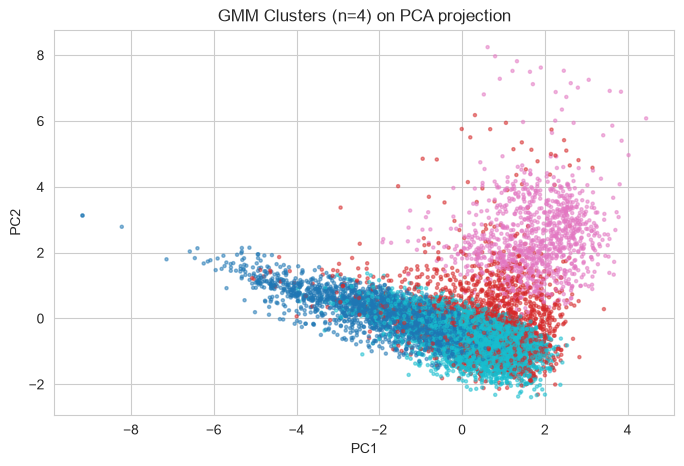

In [18]:
n_components = 4

gmm = GaussianMixture(n_components=n_components, random_state=42)
df["gmm_cluster"] = gmm.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["gmm_cluster"], cmap="tab10", s=5, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM Clusters (n={n_components}) on PCA projection")
plt.show()


## 8. t-SNE Visualization (optional, more detailed view)

t-SNE often separates clusters more visually distinctly than PCA, at the cost of
being slower and non-deterministic between runs. Here we visualize the K-Means
labels using t-SNE.


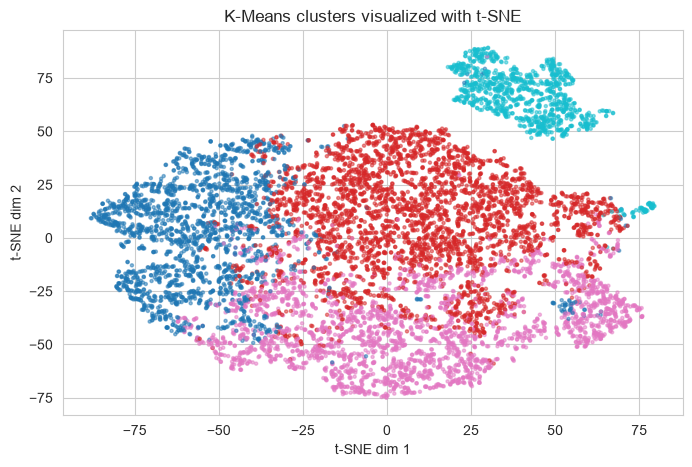

In [19]:
# t-SNE on the full 10,000 rows can take a couple of minutes; subsample if needed
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df["kmeans_cluster"], cmap="tab10", s=5, alpha=0.5)
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.title("K-Means clusters visualized with t-SNE")
plt.show()


## 9. Cluster Interpretation

Compare the average audio-feature values per K-Means cluster to understand what
kind of songs each cluster represents (e.g. "high energy, low acousticness" ->
upbeat/dance tracks; "low energy, high valence" -> ?).


In [20]:
cluster_profile = df.groupby("kmeans_cluster")[feature_cols + ["popularity"]].mean().round(2)
cluster_profile["count"] = df["kmeans_cluster"].value_counts()
cluster_profile


,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo,popularity,count
kmeans_cluster,,,,,,,,,,,
0,0.42,0.27,0.26,0.00,4.99,0.16,-16.01,0.04,107.18,35.58,2207
1,0.67,0.72,0.63,0.00,5.30,0.15,-8.97,0.07,115.76,36.77,3889
2,0.44,0.45,0.77,0.00,5.26,0.32,-7.15,0.07,137.28,36.90,2837
3,0.67,0.50,0.68,0.96,5.18,0.24,-7.21,0.23,117.73,46.29,1066


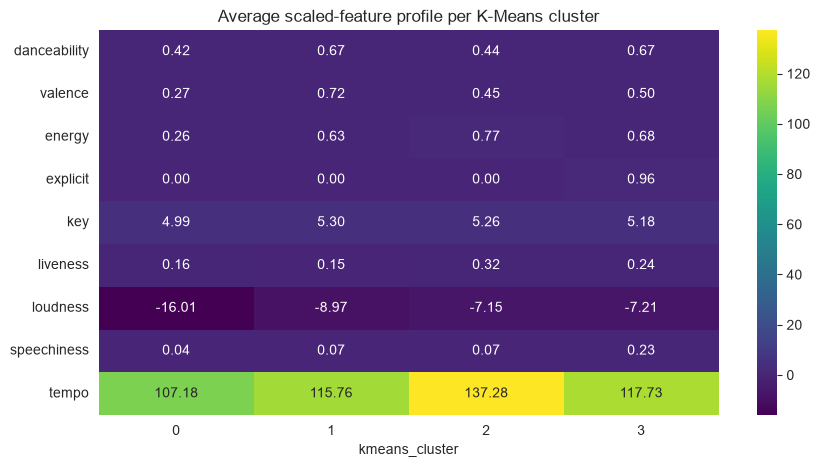

In [21]:
# Heatmap of cluster profiles for a quick visual read
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile[feature_cols].T, annot=True, cmap="viridis", fmt=".2f")
plt.title("Average scaled-feature profile per K-Means cluster")
plt.show()


In [22]:
# A few example songs from each cluster, to sanity-check the clusters make sense
for c in sorted(df["kmeans_cluster"].unique()):
    print(f"\n--- Cluster {c} ---")
    print(df[df["kmeans_cluster"] == c][["name", "artists"]].sample(5, random_state=1).to_string(index=False))



--- Cluster 0 ---
                                                                    name                                                                                                                 artists
    At Wit's End - From "Pirates of the Caribbean: At World's End"/Score                                                                                                         ['Hans Zimmer']
                                            My Roots Are Strong and Deep                                                                                                     ['The Microphones']
                                         As Canções Que Você Fez Pra Mim                                                                                                      ['Maria Bethânia']
La Sonnambula / Act 1: "Perdona, o mia diletta...Prendi: L'anel ti dono" ['Vincenzo Bellini', 'Luciano Pavarotti', 'Dame Joan Sutherland', 'National Philharmonic Orchestra', 'Richard Bonynge']
                

## 10. Comparing the Models

| Model | Needs k upfront? | Handles noise? | Cluster shape assumption |
|---|---|---|---|
| K-Means | Yes | No | Spherical, equal-sized |
| Hierarchical | No (cut dendrogram) | No | Flexible, but sensitive to linkage |
| DBSCAN | No (needs eps, min_samples) | Yes (-1 = noise) | Arbitrary shape, density-based |
| GMM | Yes | No (soft assignment) | Elliptical (covariance-based) |

**Next steps / things to try:**
- Compare silhouette scores across all 4 models on the same data.
- Try different feature subsets (e.g. drop `key`/`explicit` since they're less
  continuous than the others).
- If you can get real Spotify API access, add `acousticness` and
  `instrumentalness` as in the original brief.
- Use the cluster profiles to name each cluster (e.g. "Chill/Acoustic",
  "High-Energy Dance", "Live/Speech-heavy", "Downbeat/Sad").
